In [85]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from scipy.spatial.distance import squareform

from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression



import importlib
import bootstrap
import distribution_estimation
import plotting
import model_wrapper
import performance_comparison
# Reload modules to pick up latest changes
importlib.reload(bootstrap)
importlib.reload(distribution_estimation)
importlib.reload(plotting)
importlib.reload(model_wrapper)
importlib.reload(performance_comparison)

from bootstrap import *
from distribution_estimation import *
from plotting import *
from model_wrapper import *
from performance_comparison import *

print("Modules reloaded successfully!")

Modules reloaded successfully!


In [86]:
run0 = np.load("shap_results/bootstrap_runs/run_000/shap_results/patch_shap.npy", allow_pickle=True)

In [87]:
run0.shape

(100, 8, 8)

In [13]:
run_root = "shap_results/bootstrap_runs"
run_dirs = sorted(
    d for d in os.listdir(run_root)
    if d.startswith("run_") and os.path.isdir(os.path.join(run_root, d, "shap_results"))
)

cifar_boot_results = []

for run_name in run_dirs:
    run_idx = int(run_name.split("_")[-1])
    patch_shap = np.load(
        os.path.join(run_root, run_name, "shap_results", "patch_shap.npy"),
        allow_pickle=True,
    )

    if patch_shap.ndim != 3:
        raise ValueError(f"Expected patch_shap to have shape (n_images, n_rows, n_cols), got {patch_shap.shape}")

    abs_shap = np.abs(patch_shap)
    sum_abs_shap = abs_shap.sum(axis=0)
    mean_abs_shap = abs_shap.mean(axis=0)
    n_images, n_rows, n_cols = patch_shap.shape

    rows = []
    for row_idx in range(n_rows):
        for col_idx in range(n_cols):
            rows.append({
                "feature": f"r{row_idx}c{col_idx}",
                "bootstrap_id": run_idx,
                "perm_round": 0,
                "sum_abs_shap": float(sum_abs_shap[row_idx, col_idx]),
                "mean_abs_shap": float(mean_abs_shap[row_idx, col_idx]),
                "n_samples": int(n_images),
            })

    cifar_boot_results.append(pd.DataFrame(rows))

print(f"Loaded {len(cifar_boot_results)} runs")
print(cifar_boot_results[0].head())

Loaded 50 runs
  feature  bootstrap_id  perm_round  sum_abs_shap  mean_abs_shap  n_samples
0    r0c0             0           0      0.026760       0.000268        100
1    r0c1             0           0      0.030242       0.000302        100
2    r0c2             0           0      0.023102       0.000231        100
3    r0c3             0           0      0.024466       0.000245        100
4    r0c4             0           0      0.020315       0.000203        100


In [44]:
cifar_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cifar_boot_results,
    agg_col="sum_abs_shap",
    kernel="gaussian",
    zero_tol=1e-12,
)

cifar_feature_kde.head()

,feature,n_bootstrap_rounds,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,kde_model,mean_abs_estimated,mean_estimated,var_estimated,sd_estimated,p_nonzero,peak_density,nonzero_median
0,r0c0,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...",0.022252,0.022252,0.000029,0.005394,1.0,79.469942,0.021630
1,r0c1,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...",0.022950,0.022950,0.000030,0.005503,1.0,77.067686,0.022348
2,r0c2,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...",0.021922,0.021922,0.000029,0.005395,1.0,77.782898,0.021345
3,r0c3,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...",0.021143,0.021143,0.000028,0.005252,1.0,82.531890,0.020532
4,r0c4,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...",0.021498,0.021498,0.000027,0.005215,1.0,80.267061,0.020959


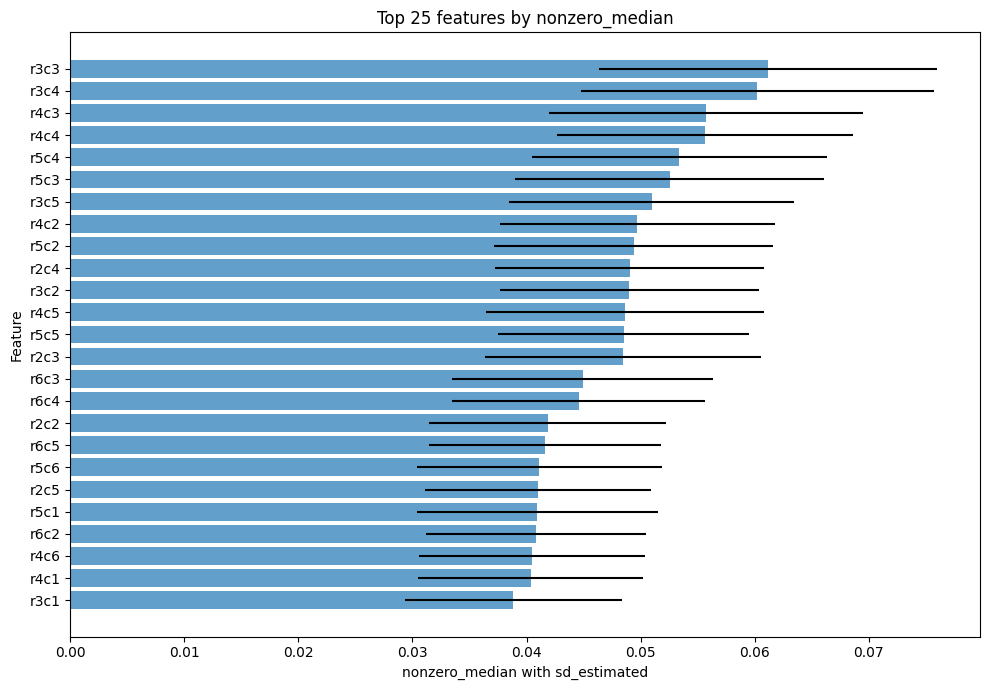

In [45]:
cifar_top_with_error = plot_top_feature_with_error(
    cifar_feature_kde,
    top_k=25,
    score_col="nonzero_median",
)

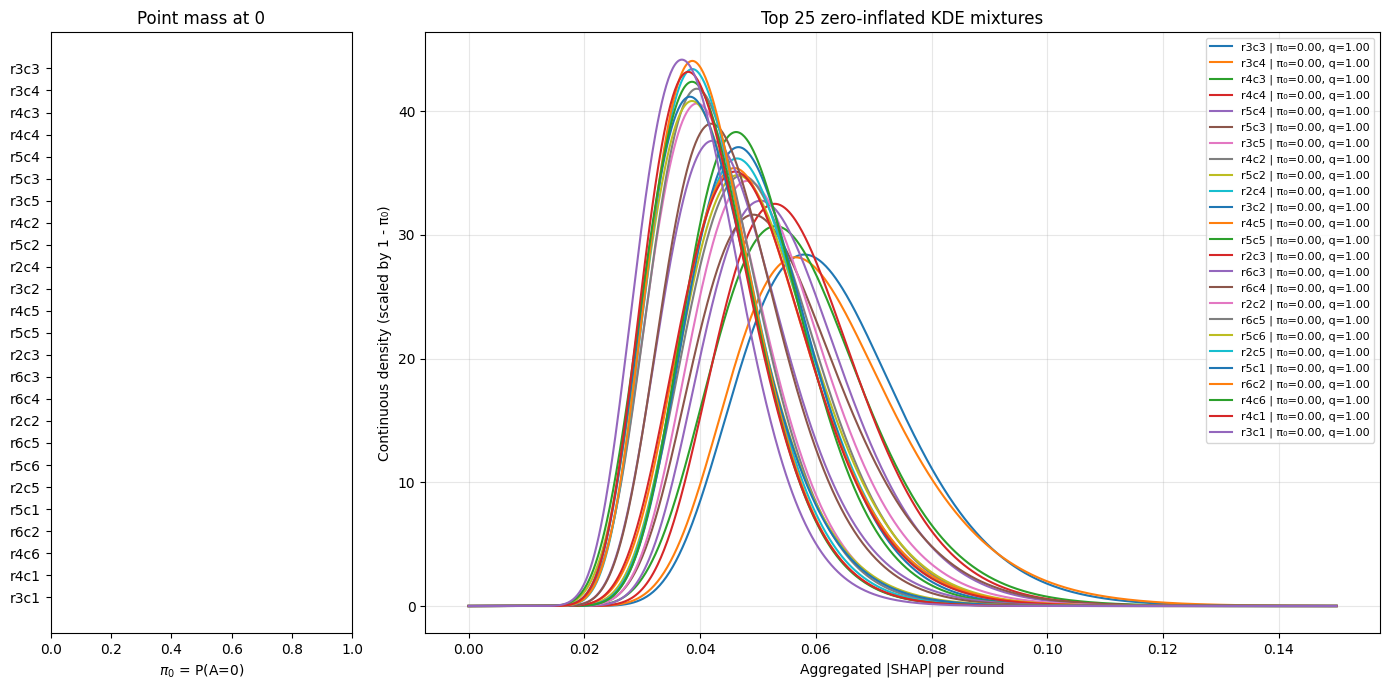

In [46]:
cifar_top_density = plot_top_feature_density(
    cifar_feature_kde,
    top_k=25,
    score_col="nonzero_median",
    x_min=0.0,
    x_max=0.15,
    log_x=False,
)

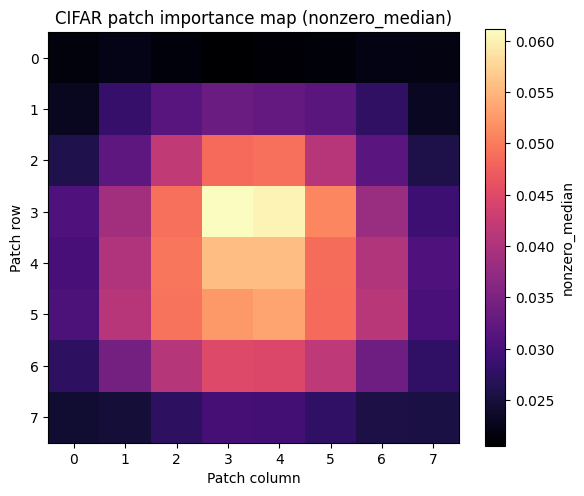

In [47]:
score_col = "nonzero_median"
patch_score_map = np.full((8, 8), np.nan)

for _, row in cifar_feature_kde.iterrows():
    feature = str(row["feature"])
    if not (feature.startswith("r") and "c" in feature):
        continue
    row_idx = int(feature[1:feature.index("c")])
    col_idx = int(feature[feature.index("c") + 1:])
    patch_score_map[row_idx, col_idx] = row[score_col]

plt.figure(figsize=(6, 5))
plt.imshow(patch_score_map, cmap="magma")
plt.colorbar(label=score_col)
plt.title(f"CIFAR patch importance map ({score_col})")
plt.xlabel("Patch column")
plt.ylabel("Patch row")
plt.xticks(range(8))
plt.yticks(range(8))
plt.tight_layout()
plt.show()

In [83]:
sample_idx = 0

cifar_sample_boot_results = []

for run_name in run_dirs:
    run_idx = int(run_name.split("_")[-1])
    patch_shap = np.load(
        os.path.join(run_root, run_name, "shap_results", "patch_shap.npy"),
        allow_pickle=True,
    )

    if sample_idx >= patch_shap.shape[0]:
        raise IndexError(f"sample_idx={sample_idx} out of bounds for {run_name} with shape {patch_shap.shape}")

    sample_patch_shap = patch_shap[sample_idx]
    n_rows, n_cols = sample_patch_shap.shape

    rows = []
    for row_idx in range(n_rows):
        for col_idx in range(n_cols):
            rows.append({
                "sample_id": sample_idx,
                "feature": f"r{row_idx}c{col_idx}",
                "bootstrap_id": run_idx,
                "perm_round": 0,
                "shap_value": float(sample_patch_shap[row_idx, col_idx]),
            })

    cifar_sample_boot_results.append(pd.DataFrame(rows))

cifar_sample_mix = estimate_sample_feature_distribution(
    cifar_sample_boot_results,
    bandwidth=0.0003,
    kernel="gaussian",
    zero_tol=1e-8,
)

print(cifar_sample_mix.head())

   sample_id feature  n_total  n_zero  n_nonzero  pi_zero  bandwidth  \
0          0    r0c0       50       0         50      0.0     0.0003   
1          0    r0c1       50       0         50      0.0     0.0003   
2          0    r0c2       50       0         50      0.0     0.0003   
3          0    r0c3       50       0         50      0.0     0.0003   
4          0    r0c4       50       0         50      0.0     0.0003   

     kernel      zero_tol                                          kde_model  
0  gaussian  1.000000e-08  {'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...  
1  gaussian  1.000000e-08  {'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...  
2  gaussian  1.000000e-08  {'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...  
3  gaussian  1.000000e-08  {'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...  
4  gaussian  1.000000e-08  {'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '...  


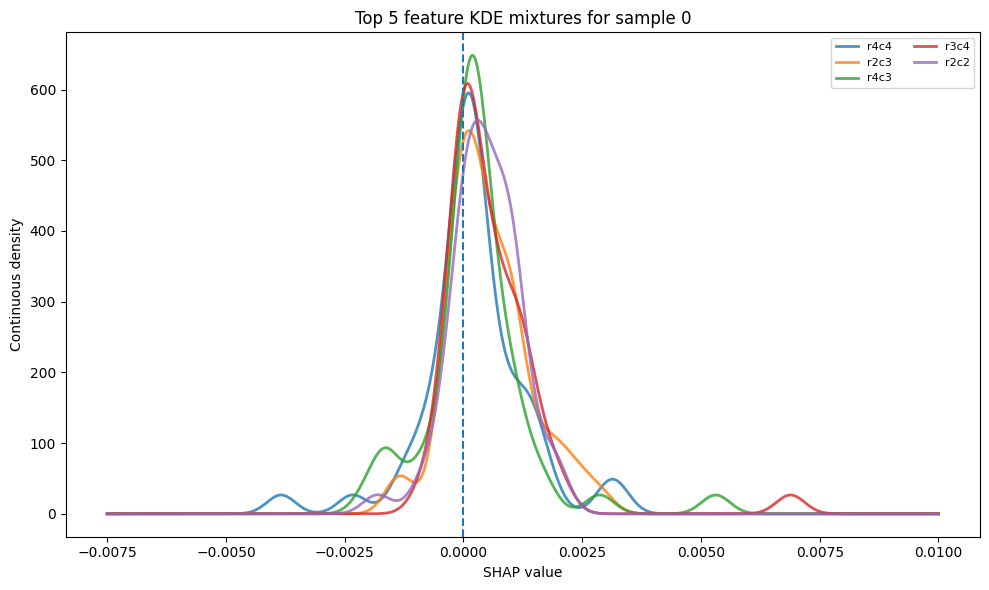

,feature,mean_abs_estimated,p_nonzero,peak_density
36,r4c4,0.000807,1.0,595.314349
19,r2c3,0.000784,1.0,542.034669
35,r4c3,0.000771,1.0,648.551198
28,r3c4,0.000767,1.0,608.582996
18,r2c2,0.000707,1.0,556.699914


In [84]:
top_df = plot_sample_top_features_overlay(
    mix_df=cifar_sample_mix,
    sample_id=0,
    class_id=None,
    top_k=5,
    rank_by="mean_abs_estimated",
    n_grid=600,
    xlim=(-0.0075, 0.01),
)
top_df[["feature", "mean_abs_estimated", "p_nonzero", "peak_density"]]

In [51]:
class_source = "true"  # change to "predicted" to group by predicted class instead
n_classes = len(class_names)

cifar_class_boot_results = []

for run_name in run_dirs:
    run_idx = int(run_name.split("_")[-1])
    run_dir = os.path.join(run_root, run_name, "shap_results")

    patch_shap = np.load(os.path.join(run_dir, "patch_shap.npy"), allow_pickle=True)
    labels = np.load(os.path.join(run_dir, "labels.npy"))
    predicted = np.load(os.path.join(run_dir, "predicted.npy"))

    class_ids = labels if class_source == "true" else predicted
    abs_shap = np.abs(patch_shap)
    _, n_rows, n_cols = abs_shap.shape

    rows = []
    for class_id in range(n_classes):
        class_mask = class_ids == class_id
        class_abs = abs_shap[class_mask]
        n_class_images = int(class_mask.sum())

        if n_class_images == 0:
            sum_abs = np.zeros((n_rows, n_cols), dtype=float)
            mean_abs = np.zeros((n_rows, n_cols), dtype=float)
        else:
            sum_abs = class_abs.sum(axis=0)
            mean_abs = class_abs.mean(axis=0)

        for row_idx in range(n_rows):
            for col_idx in range(n_cols):
                rows.append({
                    "class_id": class_id,
                    "class_name": class_names[class_id],
                    "feature": f"r{row_idx}c{col_idx}",
                    "bootstrap_id": run_idx,
                    "perm_round": 0,
                    "sum_abs_shap": float(sum_abs[row_idx, col_idx]),
                    "sum_shap": float(patch_shap[class_mask, row_idx, col_idx].sum()),
                    "mean_abs_shap": float(mean_abs[row_idx, col_idx]),
                    "n_samples": n_class_images,
                })

    cifar_class_boot_results.append(pd.DataFrame(rows))

# Choose which aggregate and support to estimate:
#   - agg_col="sum_abs_shap", support="positive"  -> nonnegative |SHAP| mass
#   - agg_col="sum_shap",     support="real"      -> signed SHAP mass
# agg_col = "sum_shap"
agg_col = "mean_estimated"
support = "real"

cifar_class_feature_kde = estimate_feature_level_mixture_preagg(
    boot_results=cifar_class_boot_results,
    agg_col=agg_col,
    kernel="gaussian",
    zero_tol=1e-12,
    support=support,
)
cifar_class_feature_kde["class_name"] = cifar_class_feature_kde["class_id"].map(dict(enumerate(class_names)))

print(f"Loaded {len(cifar_class_boot_results)} class-aggregated runs")
print(f"KDE config: agg_col={agg_col}, support={support}")
cifar_class_feature_kde.head()

ValueError: Column 'mean_estimated' not found in boot_results. Available columns include: ['bootstrap_id', 'class_id', 'class_name', 'feature', 'mean_abs_shap', 'n_samples', 'perm_round', 'sum_abs_shap', 'sum_shap']

In [52]:
class_id_to_plot = 0
class_df = cifar_class_feature_kde[cifar_class_feature_kde["class_id"] == class_id_to_plot].copy()

score_col = "mean_abs_estimated"
# score_col = "mean_estimated"
top_k = 20

# Select top features by the chosen KDE summary metric
top_features_df = (
    class_df.sort_values(score_col, ascending=False)
            .head(top_k)
            .copy()
)
feature_order = top_features_df["feature"].astype(str).tolist()

# Build run-level values for those features (same class)
class_run_df = pd.concat(cifar_class_boot_results, ignore_index=True)
class_run_df = class_run_df[class_run_df["class_id"] == class_id_to_plot].copy()

if agg_col not in class_run_df.columns:
    raise ValueError(f"agg_col '{agg_col}' not found in class run data")

box_data = []
for feat in feature_order:
    vals = class_run_df.loc[
        class_run_df["feature"].astype(str) == feat,
        agg_col,
    ].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    box_data.append(vals)

# Plot boxplot of run-level aggregated SHAP values per top feature
fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(box_data, labels=feature_order, showfliers=False)
ax.set_title(
    f"Class {class_id_to_plot} ({class_names[class_id_to_plot]}) - Top {top_k} features\n"
    f"Boxplot of {agg_col} across runs (ranked by {score_col})"
)
ax.set_xlabel("Feature")
ax.set_ylabel(agg_col)
ax.tick_params(axis="x", rotation=75)
plt.tight_layout()
plt.show()

# class_top_with_error = plot_top_feature_with_error(
#     class_df,
#     top_k=top_k,
#     score_col=score_col,
# )

# top_features_df.head()

ValueError: agg_col 'mean_estimated' not found in class run data

In [53]:
# Histogram + estimated density for each feature (class-specific)
class_id_to_plot = 0
bins = 20
features_per_page = 16
ncols = 4
nrows = 4

# Collect run-level aggregated values for this class
class_run_df = pd.concat(cifar_class_boot_results, ignore_index=True)
class_run_df = class_run_df[class_run_df["class_id"] == class_id_to_plot].copy()

# Match the aggregation column used in KDE fitting
if agg_col not in class_run_df.columns:
    raise ValueError(f"agg_col '{agg_col}' not found in class run data")

# Map feature -> fitted model row for this class
class_model_df = cifar_class_feature_kde[cifar_class_feature_kde["class_id"] == class_id_to_plot].copy()
model_by_feature = dict(zip(class_model_df["feature"].astype(str), class_model_df["kde_model"]))

features = sorted(
    class_run_df["feature"].astype(str).unique(),
    key=lambda s: (int(s[1:s.index('c')]), int(s[s.index('c') + 1:])),
)


def _density_from_model(model, xvals):
    if not isinstance(model, dict):
        return np.zeros_like(xvals, dtype=float)

    pi_zero = float(model.get("pi_zero", np.nan))
    kde = model.get("kde", None)
    support_local = model.get("support", "positive")
    zero_tol = float(model.get("zero_tol", 0.0))

    if np.isnan(pi_zero) or kde is None:
        return np.zeros_like(xvals, dtype=float)

    xvals = np.asarray(xvals, dtype=float)
    if support_local == "positive":
        y = np.zeros_like(xvals, dtype=float)
        mask = xvals > zero_tol
        if np.any(mask):
            z = np.log(xvals[mask]).reshape(-1, 1)
            y[mask] = (1.0 - pi_zero) * np.exp(kde.score_samples(z)) / xvals[mask]
        return y

    return (1.0 - pi_zero) * np.exp(kde.score_samples(xvals.reshape(-1, 1)))


n_pages = int(np.ceil(len(features) / features_per_page))

for page in range(n_pages):
    start = page * features_per_page
    end = min((page + 1) * features_per_page, len(features))
    page_features = features[start:end]

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 12), constrained_layout=True)
    axes = axes.ravel()

    for ax_idx, ax in enumerate(axes):
        if ax_idx >= len(page_features):
            ax.axis("off")
            continue

        feat = page_features[ax_idx]
        vals_all = class_run_df.loc[
            class_run_df["feature"].astype(str) == feat,
            agg_col,
        ].to_numpy(dtype=float)
        vals_all = vals_all[np.isfinite(vals_all)]

        if vals_all.size == 0:
            ax.set_title(feat)
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue

        model = model_by_feature.get(feat)
        support_local = model.get("support", support) if isinstance(model, dict) else support
        zero_tol = float(model.get("zero_tol", 0.0)) if isinstance(model, dict) else 0.0
        pi_zero = float(model.get("pi_zero", np.nan)) if isinstance(model, dict) else np.nan

        # Continuous-part histogram density to match zero-inflated KDE curve
        if support_local == "positive":
            is_zero = vals_all <= zero_tol
        else:
            is_zero = np.abs(vals_all) <= zero_tol
        vals_nonzero = vals_all[~is_zero]

        if vals_nonzero.size > 0:
            bin_counts, bin_edges = np.histogram(vals_nonzero, bins=bins)
            bin_widths = np.diff(bin_edges)
            hist_density = bin_counts / (vals_nonzero.size * bin_widths)
            scale = 1.0 - (float(np.mean(is_zero)) if not np.isfinite(pi_zero) else pi_zero)
            hist_density = hist_density * max(scale, 0.0)
            ax.bar(
                bin_edges[:-1],
                hist_density,
                width=bin_widths,
                align="edge",
                alpha=0.35,
                edgecolor="black",
                color="tab:blue",
                label="hist density (scaled)",
                zorder=1,
            )
            x_lo, x_hi = float(bin_edges[0]), float(bin_edges[-1])
        else:
            x_lo, x_hi = float(np.min(vals_all)), float(np.max(vals_all))
            if x_hi <= x_lo:
                x_lo, x_hi = x_lo - 1e-6, x_hi + 1e-6

        pad = 0.08 * (x_hi - x_lo)
        if support_local == "positive":
            x_lo = max(0.0, x_lo - pad)
        else:
            x_lo = x_lo - pad
        x_hi = x_hi + pad

        x = np.linspace(x_lo, x_hi, 500)
        y = _density_from_model(model, x)

        # Plot KDE on a secondary axis so it remains visible even when scales differ.
        ax_kde = ax.twinx()
        ax_kde.plot(x, y, color="crimson", linewidth=2.0, label="kde", zorder=3)
        ax_kde.tick_params(labelsize=7, colors="crimson")
        ax_kde.set_ylabel("kde", color="crimson", fontsize=8)

        if np.all(~np.isfinite(y)) or np.nanmax(np.abs(y)) == 0:
            ax.text(0.03, 0.92, "kde ~ 0", transform=ax.transAxes, fontsize=7, color="crimson")

        ax.set_title(feat)
        ax.tick_params(labelsize=8)

    # One legend for histogram/KDE style
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color="tab:blue", linewidth=8, alpha=0.35, label="hist density (scaled)"),
        Line2D([0], [0], color="crimson", linewidth=2, label="kde"),
    ]
    fig.legend(handles=legend_handles, loc="upper right")
    fig.suptitle(
        f"Class {class_id_to_plot} ({class_names[class_id_to_plot]}) - feature histograms + estimated density\n"
        f"agg_col={agg_col}, support={support}, page {page+1}/{n_pages}",
        y=1.02,
    )
    plt.show()

ValueError: agg_col 'mean_estimated' not found in class run data

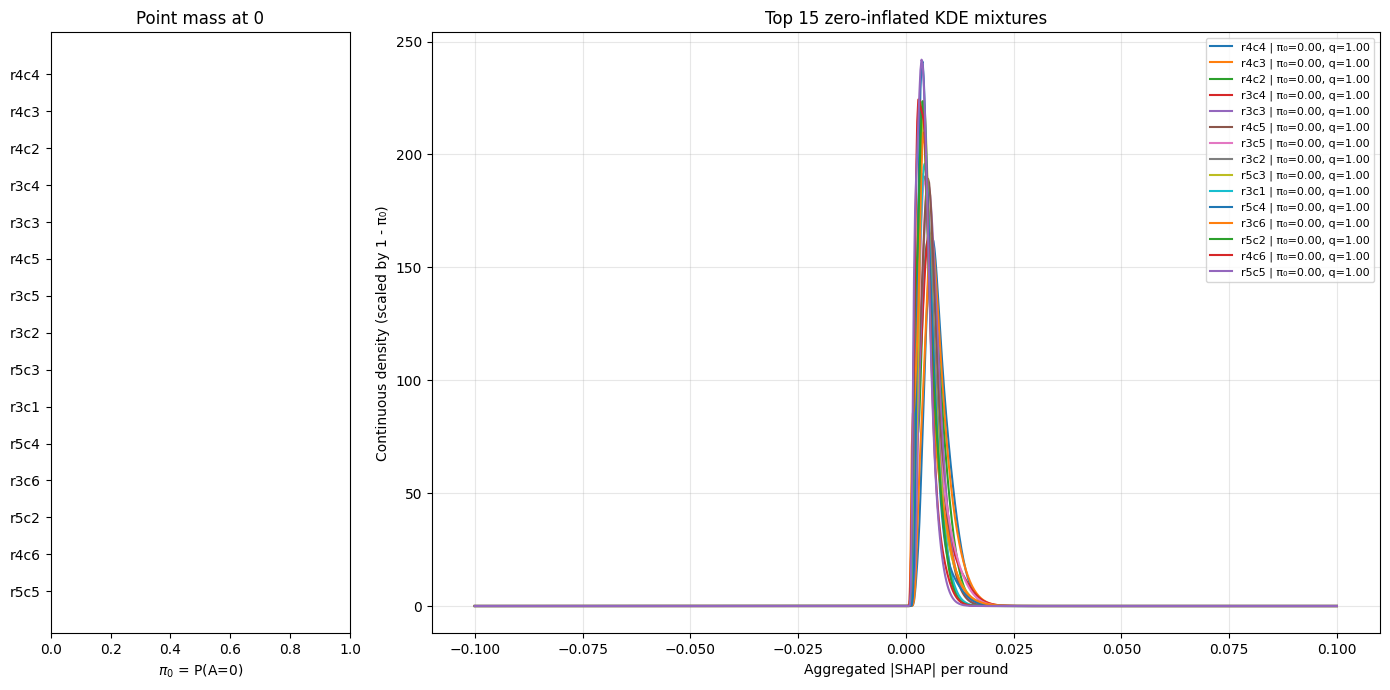

,feature,class_id,n_bootstrap_rounds,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,...,median,nonzero_median_kde,class_name,mean_abs_estimated,mean_estimated,var_estimated,sd_estimated,p_nonzero,peak_density,nonzero_median
0,r4c4,0,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,...,0.006714,0.007138,airplane,0.007505,0.007505,0.000008,0.002807,1.0,162.852938,0.007138
1,r4c3,0,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,...,0.006699,0.006973,airplane,0.007301,0.007301,0.000009,0.003079,1.0,161.360273,0.006973
2,r4c2,0,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,...,0.006104,0.005961,airplane,0.006418,0.006418,0.000007,0.002554,1.0,150.843170,0.005961
3,r3c4,0,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,...,0.006053,0.005962,airplane,0.006380,0.006380,0.000009,0.003070,1.0,157.306650,0.005962
4,r3c3,0,50,50,0,50,0.0,0.2,gaussian,1.000000e-12,...,0.005811,0.005895,airplane,0.005980,0.005980,0.000007,0.002562,1.0,168.808366,0.005895


In [54]:
# Top 15 feature estimated density plot (for selected class)
class_id_to_plot = 0
score_col = "median"

top15_df = cifar_class_feature_kde[cifar_class_feature_kde["class_id"] == class_id_to_plot].copy()

x_lo = float(top15_df[score_col].min())
x_hi = float(top15_df[score_col].max())
if x_lo == x_hi:
    x_lo, x_hi = x_lo - 1e-6, x_hi + 1e-6
x_pad = 0.1 * max(abs(x_lo), abs(x_hi), 1e-6)

class_top15_density = plot_top_feature_density(
    top15_df,
    top_k=15,
    score_col=score_col,
    x_min=-0.1,
    x_max=0.1,
    log_x=False,
)

class_top15_density.head()

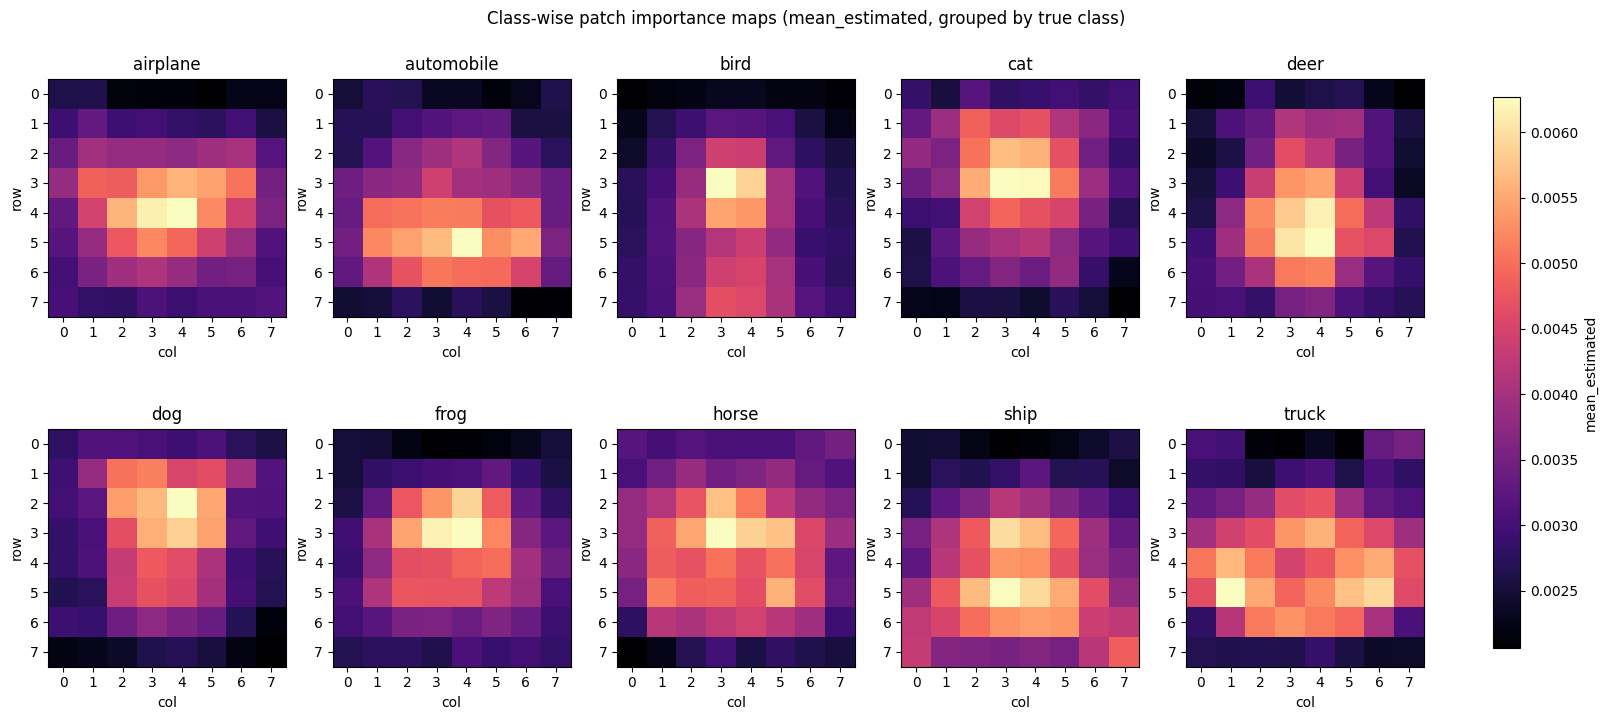

In [55]:
score_col = "mean_estimated"
fig, axes = plt.subplots(2, 5, figsize=(16, 7), constrained_layout=True)
axes = axes.ravel()

for class_id, ax in enumerate(axes):
    class_df = cifar_class_feature_kde[cifar_class_feature_kde["class_id"] == class_id]
    patch_score_map = np.full((8, 8), np.nan)

    for _, row in class_df.iterrows():
        feature = str(row["feature"])
        row_idx = int(feature[1:feature.index("c")])
        col_idx = int(feature[feature.index("c") + 1:])
        patch_score_map[row_idx, col_idx] = row[score_col]

    im = ax.imshow(patch_score_map, cmap="magma")
    ax.set_title(class_names[class_id])
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xlabel("col")
    ax.set_ylabel("row")

fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label=score_col)
plt.suptitle(f"Class-wise patch importance maps ({score_col}, grouped by {class_source} class)", y=1.02)
plt.show()

In [56]:
cifar_sample_mix

,sample_id,feature,n_total,n_zero,n_nonzero,pi_zero,bandwidth,kernel,zero_tol,kde_model
0,0,r0c0,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
1,0,r0c1,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
2,0,r0c2,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
3,0,r0c3,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
4,0,r0c4,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
...,...,...,...,...,...,...,...,...,...,...
59,0,r7c3,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
60,0,r7c4,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
61,0,r7c5,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."
62,0,r7c6,50,0,50,0.0,0.0002,gaussian,1.000000e-12,"{'pi_zero': 0.0, 'n_total': 50, 'n_zero': 0, '..."


In [ ]:
sample_idx = 0
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

images0 = np.load(os.path.join(run_root, "run_001", "shap_results", "images.npy"))
labels0 = np.load(os.path.join(run_root, "run_001", "shap_results", "labels.npy"))
predicted0 = np.load(os.path.join(run_root, "run_001", "shap_results", "predicted.npy"))
patch_shap0 = np.load(os.path.join(run_root, "run_001", "shap_results", "patch_shap.npy"))

image0 = images0[sample_idx]
patch_map0 = patch_shap0[sample_idx]
overlay0 = np.repeat(np.repeat(np.abs(patch_map0), 4, axis=0), 4, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image0)
axes[0].set_title(
    f"Image {sample_idx}\ntrue={class_names[int(labels0[sample_idx])]}\npred={class_names[int(predicted0[sample_idx])]}"
)
axes[0].axis("off")

im1 = axes[1].imshow(patch_map0, cmap="coolwarm")
axes[1].set_title("8x8 patch SHAP map")
axes[1].set_xlabel("Patch column")
axes[1].set_ylabel("Patch row")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(image0)
im2 = axes[2].imshow(overlay0, cmap="magma", alpha=0.45)
axes[2].set_title("|SHAP| overlay on image")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()